# Análisis Exploratorio de Datos — Estrés Hídrico en Parcelas Aguacateras
## Avance 1: Análisis Exploratorio y Preprocesamiento

**Objetivo General:**
Describir e integrar datos geoespaciales y espectrales de 100 parcelas aguacateras en Jalisco, caracterizar distribuciones,
identificar anomalías y preparar el dataset para modelado predictivo de estrés hídrico.

**Alcance:**
- Análisis de estructura de datos (formas, tipos, valores faltantes)
- Estadísticas descriptivas univariantes
- Análisis bi/multivariante de correlaciones
- Preprocesamiento (limpieza, normalización, manejo de outliers)
- Conclusiones y patrones identificados

**Fuentes de datos:**
- aguacates_jalisco_5_5_26.kml — 100 parcelas
- aguacate_jalisco_monthly_indices_2023_2026.csv — 4000 observaciones

**Fecha:** Mayo 8, 2026

---
## 0. Configuración del Entorno

In [85]:
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from scipy.stats import skew, kurtosis, shapiro
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import rasterio
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid', palette='viridis')

KML_PATH = r"C:\Users\omarh\Desktop\Maestria\aguacates_jalisco_5_5_26.kml"
CSV_PATH = r"C:\Users\omarh\Desktop\Maestria\aguacate_jalisco_monthly_indices_2023_2026.csv"

print('✓ Entorno configurado')

✓ Entorno configurado


---
## 1. Estructura de los Datos

In [86]:
def parse_kml_to_gdf(path: str) -> gpd.GeoDataFrame:
    tree = ET.parse(path)
    root = tree.getroot()
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    records = []
    for pm in root.findall('.//kml:Placemark', ns):
        name = pm.find('kml:name', ns).text
        coords_raw = pm.find('.//kml:coordinates', ns).text.strip()
        lon, lat, alt = map(float, coords_raw.split(','))
        num = int(''.join(filter(str.isdigit, name)))
        records.append({
            'parcela': name, 'num': num, 'lon': lon, 'lat': lat,
            'altitud_kml': alt, 'geometry': Point(lon, lat)
        })
    gdf = gpd.GeoDataFrame(records, crs='EPSG:4326')
    return gdf.sort_values('num').reset_index(drop=True)

gdf = parse_kml_to_gdf(KML_PATH)
print(f'Forma KML: {gdf.shape}')
print(f'Valores faltantes: {gdf.isnull().sum().sum()}')
display(gdf.head())

Forma KML: (100, 6)
Valores faltantes: 0


,parcela,num,lon,lat,altitud_kml,geometry
0,H1,1,-103.487470,19.663164,0.0,POINT (-103.48747 19.66316)
1,H2,2,-103.491681,19.659585,0.0,POINT (-103.49168 19.65958)
2,H3,3,-103.495946,19.649232,0.0,POINT (-103.49595 19.64923)
3,H4,4,-103.493425,19.648928,0.0,POINT (-103.49342 19.64893)
4,H5,5,-103.490541,19.647687,0.0,POINT (-103.49054 19.64769)


### 1.2 Carga de Índices Espectrales

In [87]:
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['name', 'date']).reset_index(drop=True)

print(f'Forma CSV: {df.shape}')
print(f'Período: {df["date"].min()} a {df["date"].max()}')
print(f'Parcelas únicas: {df["name"].nunique()}')
print(f'Valores faltantes: {df.isnull().sum().sum()}')
display(df.head())

Forma CSV: (4000, 9)
Período: 2023-01-01 00:00:00 a 2026-04-01 00:00:00
Parcelas únicas: 100
Valores faltantes: 0


,name,lat,lon,year,month,date,image_count,NDVI,NDMI
0,H1,19.663164,-103.48747,2023,1,2023-01-01,4,0.319492,-0.063829
1,H1,19.663164,-103.48747,2023,2,2023-02-01,6,0.240143,-0.107686
2,H1,19.663164,-103.48747,2023,3,2023-03-01,6,0.218621,-0.139270
3,H1,19.663164,-103.48747,2023,4,2023-04-01,6,0.194678,-0.141275
4,H1,19.663164,-103.48747,2023,5,2023-05-01,6,0.197294,-0.153916


### 1.3 Estadísticas Descriptivas

In [88]:
numeric_cols = ['lat', 'lon', 'NDVI', 'NDMI']
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
display(df[numeric_cols].describe().round(4))

print(f'\nNDVI: media={df["NDVI"].mean():.4f}, sesgo={skew(df["NDVI"]):.4f}')
print(f'NDMI: media={df["NDMI"].mean():.4f}, sesgo={skew(df["NDMI"]):.4f}')

=== ESTADÍSTICAS DESCRIPTIVAS ===


,lat,lon,NDVI,NDMI
count,4000.0000,4000.0000,4000.0000,4000.0000
mean,19.6235,-103.4952,0.5085,0.0572
std,0.0141,0.0170,0.1383,0.1184
min,19.6021,-103.5269,0.0404,-0.2626
25%,19.6127,-103.5092,0.4023,-0.0296
50%,19.6211,-103.4935,0.5161,0.0657
75%,19.6339,-103.4856,0.6131,0.1461
max,19.6632,-103.4601,0.8664,0.3765



NDVI: media=0.5085, sesgo=-0.1558
NDMI: media=0.0572, sesgo=-0.1629


### 1.4 Cardinalidad y frecuencia de variables
La variable categórica principal es **`name`**, que identifica 100 parcelas (H1–H100).
Las variables temporales `year` y `month` permiten analizar la dimensión temporal.
En esta sección calculamos la cardinalidad de cada variable y exploramos la distribución de observaciones por parcela, año y mes.


In [89]:
print('=== CARDINALIDAD Y FRECUENCIA ===')
for col in ['name', 'year', 'month']:
    print(f'{col}: {df[col].nunique()} valores únicos')

print('Frecuencia de parcelas (top 5):')
print(df['name'].value_counts().head())

# Distribución de años y meses
display(df['year'].value_counts().sort_index())
display(df['month'].value_counts().sort_index())


=== CARDINALIDAD Y FRECUENCIA ===
name: 100 valores únicos
year: 4 valores únicos
month: 12 valores únicos
Frecuencia de parcelas (top 5):
name
H1      40
H10     40
H100    40
H11     40
H12     40
Name: count, dtype: int64


year
2023    1200
2024    1200
2025    1200
2026     400
Name: count, dtype: int64

month
1     400
2     400
3     400
4     400
5     300
6     300
7     300
8     300
9     300
10    300
11    300
12    300
Name: count, dtype: int64

---
## 2. Análisis Univariante

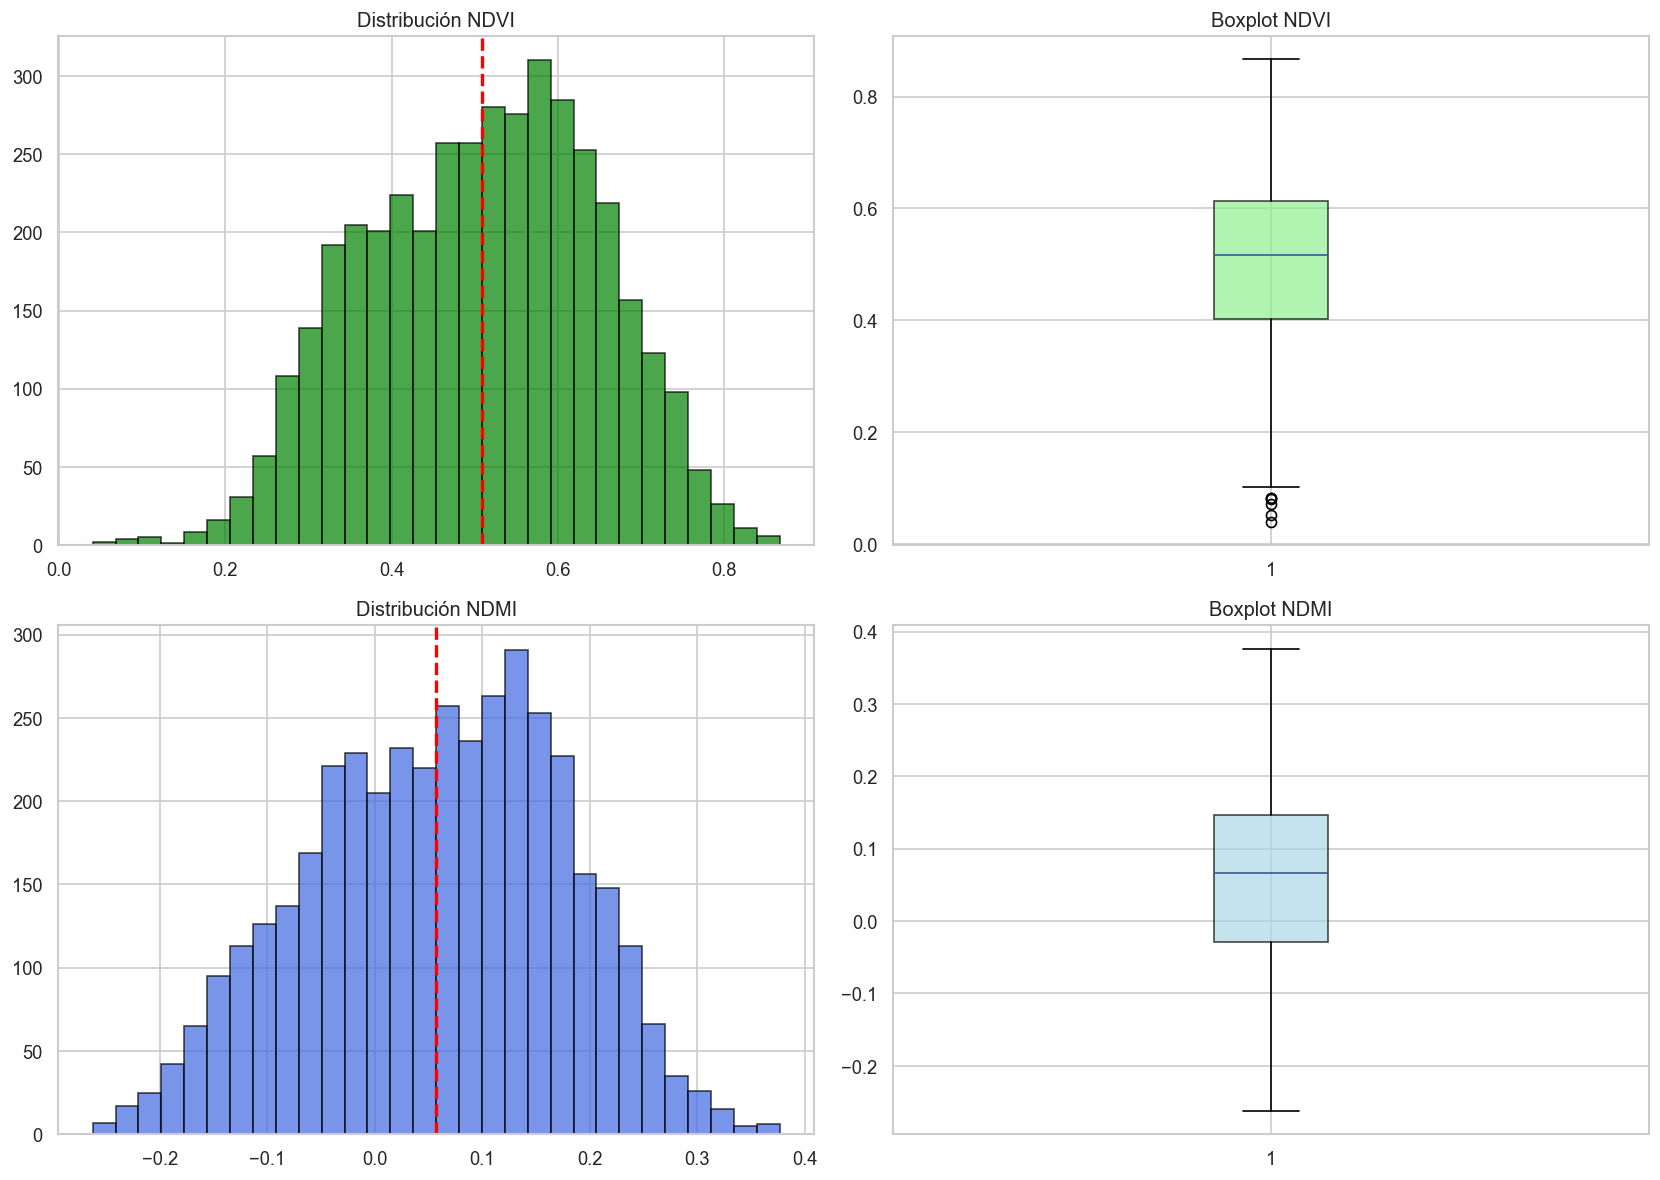

✓ Distribuciones visualizadas


In [90]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['NDVI'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['NDVI'].mean(), color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Distribución NDVI')

axes[0, 1].boxplot(df['NDVI'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[0, 1].set_title('Boxplot NDVI')

axes[1, 0].hist(df['NDMI'], bins=30, color='royalblue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df['NDMI'].mean(), color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Distribución NDMI')

axes[1, 1].boxplot(df['NDMI'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1, 1].set_title('Boxplot NDMI')

plt.tight_layout()
plt.show()
print('✓ Distribuciones visualizadas')

### 2.3 Análisis de valores atípicos
Para detectar valores atípicos (outliers) se utilizan los límites de Tukey basados en 1.5 veces el rango intercuartílico (IQR).
Esto nos ayuda a identificar observaciones de NDVI y NDMI que se encuentran fuera de los rangos típicos.
Los outliers no se eliminan automáticamente porque pueden reflejar condiciones reales, como vegetación muy escasa o estrés hídrico severo.


In [91]:
def iqr_outlier_summary(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return pd.Series({
        'Q1': q1, 'Q3': q3, 'IQR': iqr, 'Lower bound': lower,
        'Upper bound': upper, 'Outliers': len(outliers),
        'Outlier %': len(outliers) / len(data) * 100
    })

outlier_summary = pd.DataFrame({
    'NDVI': iqr_outlier_summary(df, 'NDVI'),
    'NDMI': iqr_outlier_summary(df, 'NDMI')
})

display(outlier_summary.round(4))


,NDVI,NDMI
Q1,0.4023,-0.0296
Q3,0.6131,0.1461
IQR,0.2108,0.1757
Lower bound,0.0860,-0.2932
Upper bound,0.9294,0.4097
Outliers,6.0000,0.0000
Outlier %,0.1500,0.0000


### 2.2 Distribución Temporal

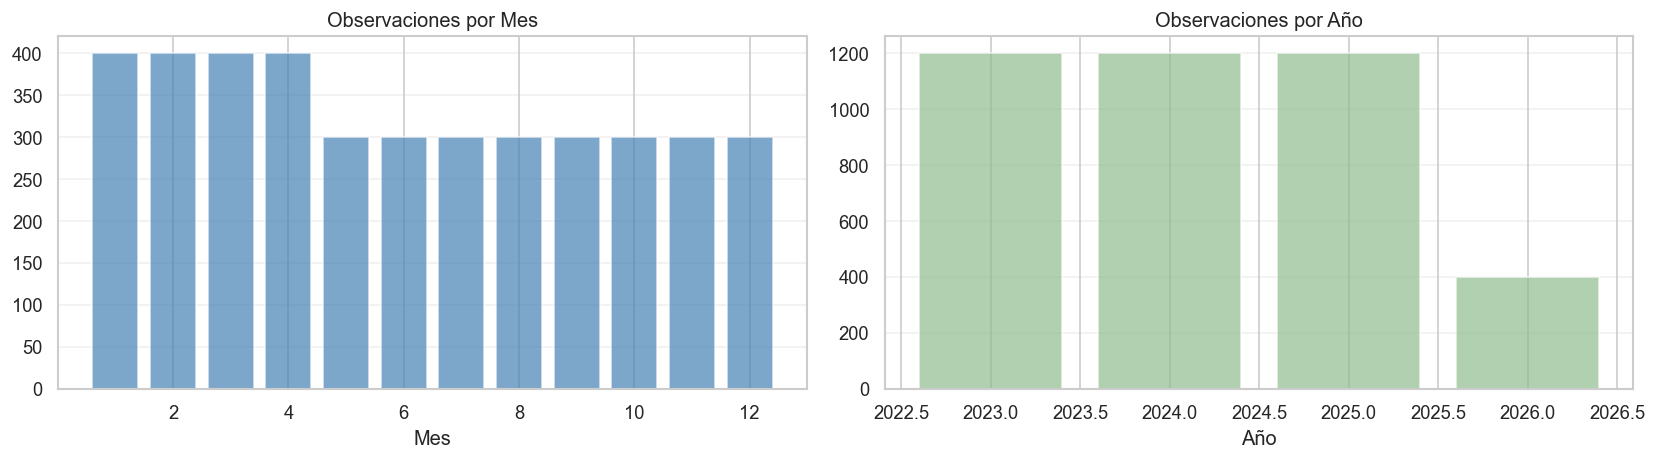

✓ Distribución temporal visualizada


In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

month_counts = df.groupby('month').size()
axes[0].bar(month_counts.index, month_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Mes')
axes[0].set_title('Observaciones por Mes')
axes[0].grid(alpha=0.3, axis='y')

year_counts = df.groupby('year').size()
axes[1].bar(year_counts.index, year_counts.values, color='darkseagreen', alpha=0.7)
axes[1].set_xlabel('Año')
axes[1].set_title('Observaciones por Año')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print('✓ Distribución temporal visualizada')

---
## 3. Análisis Bivariante

=== MATRIZ DE CORRELACIÓN ===
               NDVI    NDMI  image_count
NDVI         1.0000  0.7467      -0.1095
NDMI         0.7467  1.0000      -0.2812
image_count -0.1095 -0.2812       1.0000


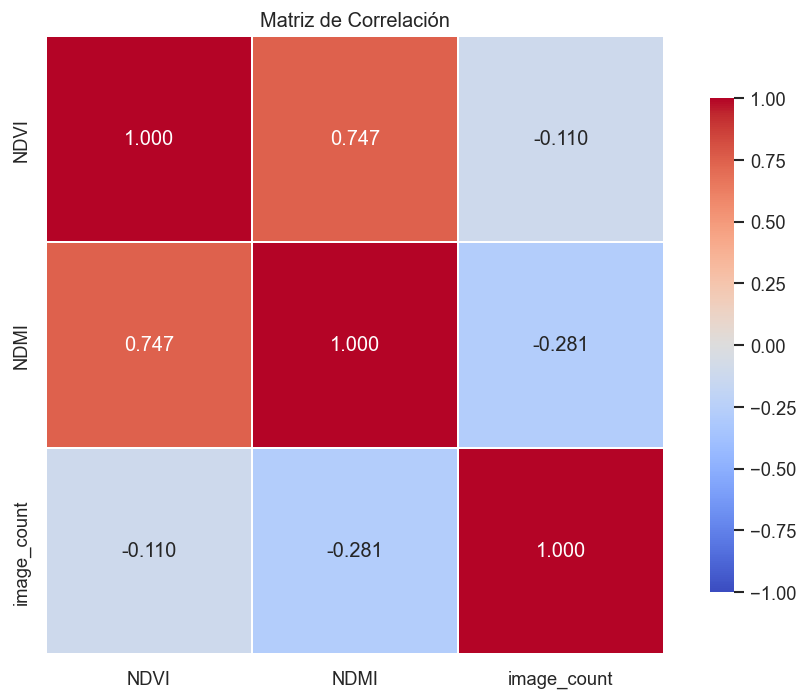

In [93]:
corr_matrix = df[['NDVI', 'NDMI', 'image_count']].corr()
print('=== MATRIZ DE CORRELACIÓN ===')
print(corr_matrix.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax,
            vmin=-1, vmax=1, fmt='.3f')
ax.set_title('Matriz de Correlación')
plt.tight_layout()
plt.show()

### 3.2 Scatter Plot NDVI vs NDMI

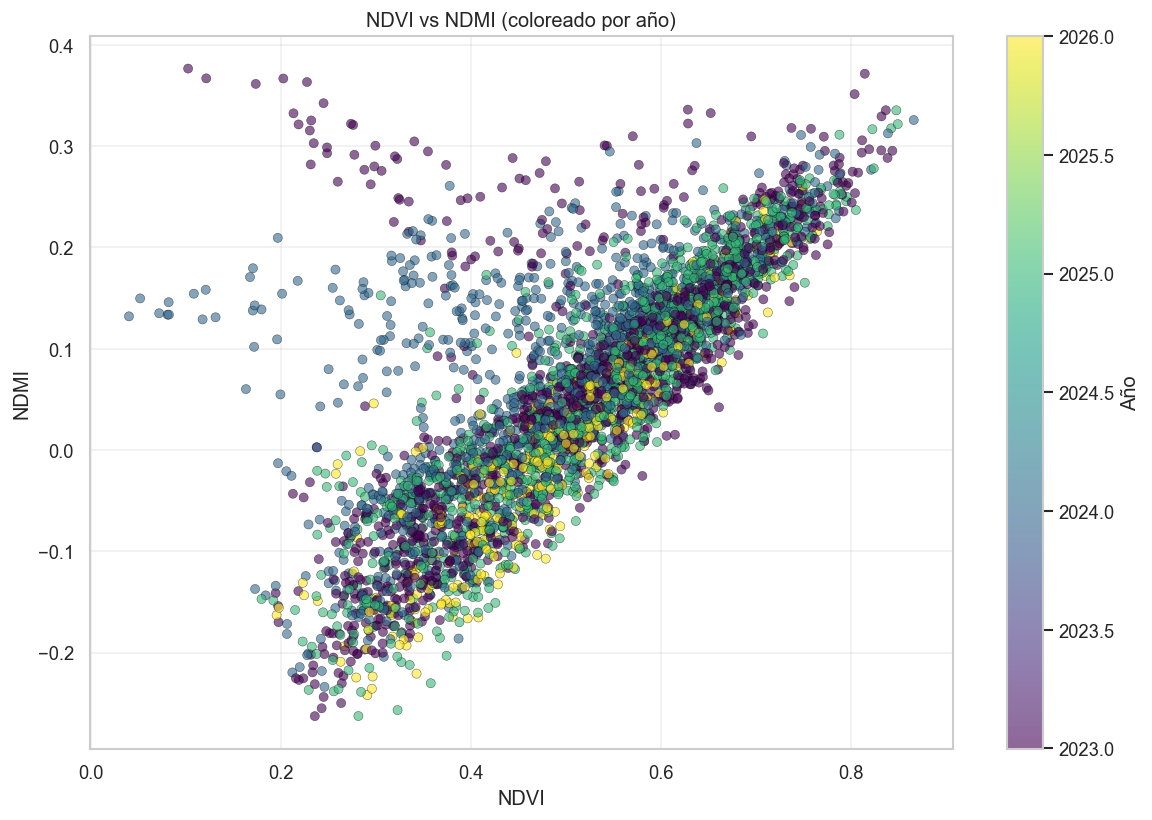

In [94]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df['NDVI'], df['NDMI'], c=df['year'], cmap='viridis',
                    alpha=0.6, s=30, edgecolor='black', linewidth=0.3)
ax.set_xlabel('NDVI')
ax.set_ylabel('NDMI')
ax.set_title('NDVI vs NDMI (coloreado por año)')
ax.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año')
plt.tight_layout()
plt.show()

### 3.3 Tendencias Temporales

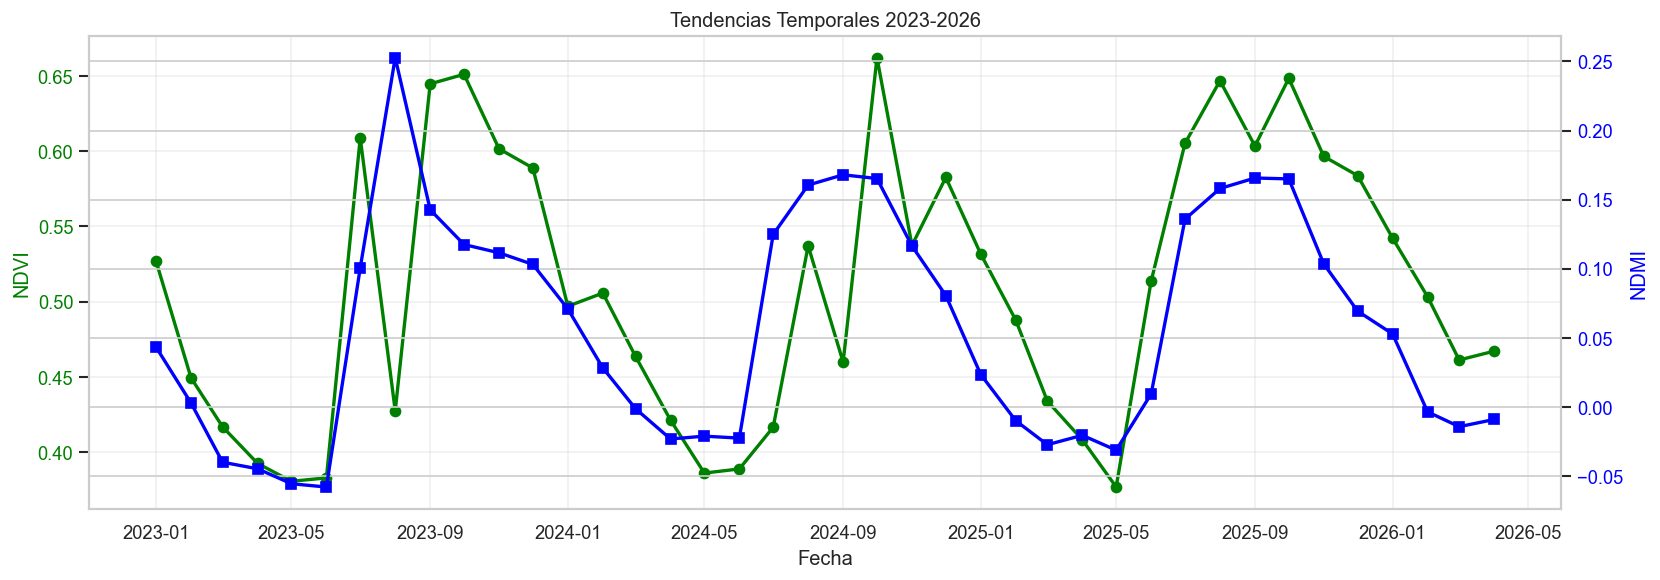

✓ Patrones estacionales identificados


In [95]:
monthly_means = df.groupby('date')[['NDVI', 'NDMI']].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_means.index, monthly_means['NDVI'], marker='o',
        label='NDVI', linewidth=2, color='green')
ax2 = ax.twinx()
ax2.plot(monthly_means.index, monthly_means['NDMI'], marker='s',
         label='NDMI', linewidth=2, color='blue')

ax.set_xlabel('Fecha')
ax.set_ylabel('NDVI', color='green')
ax2.set_ylabel('NDMI', color='blue')
ax.set_title('Tendencias Temporales 2023-2026')
ax.tick_params(axis='y', labelcolor='green')
ax2.tick_params(axis='y', labelcolor='blue')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ Patrones estacionales identificados')

---
## 4. Preprocesamiento

In [96]:
print('=== VALIDACIÓN DE RANGOS ===')
ndvi_valid = df[(df['NDVI'] >= -1) & (df['NDVI'] <= 1)].shape[0]
ndmi_valid = df[(df['NDMI'] >= -1) & (df['NDMI'] <= 1)].shape[0]

print(f'NDVI válidos: {ndvi_valid}/{len(df)} ({ndvi_valid/len(df)*100:.1f}%) ✓')
print(f'NDMI válidos: {ndmi_valid}/{len(df)} ({ndmi_valid/len(df)*100:.1f}%) ✓')

df_clean = df[
    (df['NDVI'].between(-1, 1)) &
    (df['NDMI'].between(-1, 1))
].copy()

print(f'\nDataset limpio: {df_clean.shape[0]} filas')

=== VALIDACIÓN DE RANGOS ===
NDVI válidos: 4000/4000 (100.0%) ✓
NDMI válidos: 4000/4000 (100.0%) ✓

Dataset limpio: 4000 filas


### 4.2 Test de Normalidad

In [97]:
print('=== TEST DE NORMALIDAD ===')

sample_size = min(5000, len(df_clean))
for col in ['NDVI', 'NDMI']:
    stat, p = shapiro(df_clean[col].sample(sample_size))
    print(f'{col}: p-value = {p:.6f}', end='')
    if p > 0.05:
        print(' (Normal)')
    else:
        print(' (No normal)')
    print(f'  Sesgo: {skew(df_clean[col]):.4f}')
    print(f'  Curtosis: {kurtosis(df_clean[col]):.4f}')

=== TEST DE NORMALIDAD ===
NDVI: p-value = 0.000000 (No normal)
  Sesgo: -0.1558
  Curtosis: -0.5986
NDMI: p-value = 0.000000 (No normal)
  Sesgo: -0.1629
  Curtosis: -0.5894


### 4.3 Normalización

In [98]:
df_norm = df_clean.copy()

scaler_std = StandardScaler()
df_norm[['NDVI_std', 'NDMI_std']] = scaler_std.fit_transform(df_clean[['NDVI', 'NDMI']])

scaler_minmax = MinMaxScaler()
df_norm[['NDVI_minmax', 'NDMI_minmax']] = scaler_minmax.fit_transform(df_clean[['NDVI', 'NDMI']])

print('✓ Normalización completada (Z-score + MinMax)')
print(f'Dataset normalizado: {df_norm.shape}')

✓ Normalización completada (Z-score + MinMax)
Dataset normalizado: (4000, 13)


### 4.4 Etiquetado preliminar de estrés hídrico
Se define una etiqueta preliminar de estrés hídrico utilizando percentiles de NDMI.
Los valores menores o iguales al percentil 10 se clasifican como `severe_possible_stress`,
los valores entre el percentil 10 y el 25 como `moderate_possible_stress`, y los valores superiores
al percentil 25 como `no_relative_stress`. Esta etiqueta es relativa, basada en la distribución interna del dataset.
Se analiza la distribución de clases para evaluar el desequilibrio.


,count,percentage
stress_class,,
no_relative_stress,3000,75.0
moderate_possible_stress,600,15.0
severe_possible_stress,400,10.0


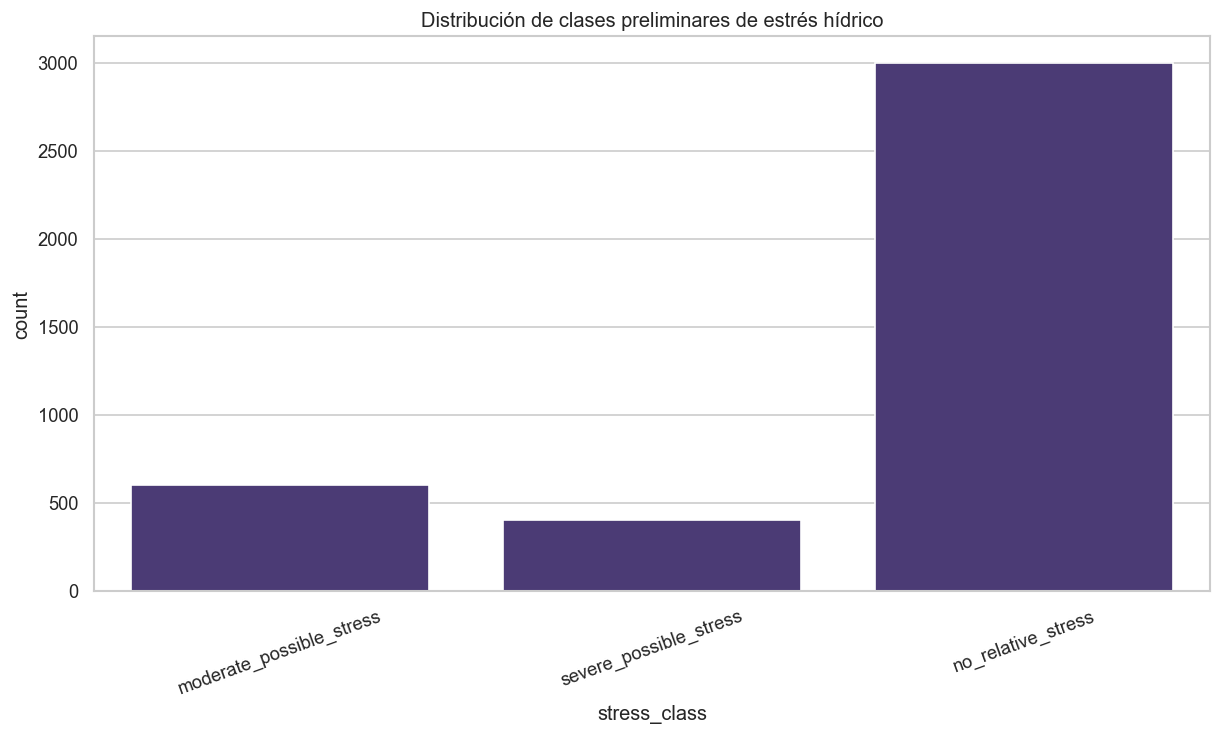

In [99]:
# Crear copia del dataset normalizado para etiquetado
df_class = df_norm.copy()

# Calcular percentiles para NDMI
q25 = df_class['NDMI'].quantile(0.25)
q10 = df_class['NDMI'].quantile(0.10)

def classify_relative_stress(ndmi):
    if ndmi <= q10:
        return 'severe_possible_stress'
    elif ndmi <= q25:
        return 'moderate_possible_stress'
    else:
        return 'no_relative_stress'

df_class['stress_class'] = df_class['NDMI'].apply(classify_relative_stress)

# Conteo y porcentaje de clases
stress_counts = df_class['stress_class'].value_counts()
stress_pct = df_class['stress_class'].value_counts(normalize=True) * 100

display(pd.DataFrame({'count': stress_counts, 'percentage': stress_pct.round(2)}))

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_class, x='stress_class')
plt.title('Distribución de clases preliminares de estrés hídrico')
plt.xticks(rotation=20)
plt.show()


El análisis de Nivel 1 generó una serie temporal mensual de NDVI y NDMI para 100 puntos de referencia de aguacate en Jalisco, desde 2023 hasta 2026. El NDVI se utilizó como indicador de vigor de la vegetación, mientras que el NDMI se empleó como indicador indirecto de humedad. Se aplicó un umbral relativo basado en los percentiles más bajos de NDMI para identificar periodos y parcelas con posible estrés hídrico. Los resultados muestran patrones estacionales, con porcentajes más altos de posible estrés durante algunos meses de la estación seca. Estos resultados deben interpretarse como indicadores preliminares y requieren validación mediante inspección visual, imágenes de mayor resolución, experiencia agronómica o datos de campo.

In [100]:
geotiff_dir = Path(r"C:\Users\omarh\Desktop\Maestria")

tif_path = geotiff_dir / "level2_priority_avocado_stack_2024_04.tif"

with rasterio.open(tif_path) as src:
    print("File:", tif_path.name)
    print("CRS:", src.crs)
    print("Width, height:", src.width, src.height)
    print("Band count:", src.count)
    print("Bounds:", src.bounds)
    print("Band descriptions:", src.descriptions)
    data = src.read()

print("Data shape:", data.shape)
print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))

File: level2_priority_avocado_stack_2024_04.tif
CRS: EPSG:4326
Width, height: 276 294
Band count: 7
Bounds: BoundingBox(left=-103.49301742131343, bottom=19.619385468227176, right=-103.46822391947173, top=19.64579593758029)
Band descriptions: ('B2', 'B3', 'B4', 'B8', 'B11', 'NDVI', 'NDMI')
Data shape: (7, 294, 276)
Min: -0.67028546
Max: 0.9372284


In [101]:
def normalize_for_display(arr, p_low=2, p_high=98):
    """
    Normalize array using percentiles for nicer visualization.
    """
    arr = arr.astype("float32")
    low, high = np.nanpercentile(arr, [p_low, p_high])
    if high - low == 0:
        return np.zeros_like(arr)
    arr = (arr - low) / (high - low)
    return np.clip(arr, 0, 1)


def plot_geotiff_stack(tif_path):
    with rasterio.open(tif_path) as src:
        stack = src.read().astype("float32")   
    blue = stack[0]
    green = stack[1]
    red = stack[2]
    ndvi = stack[5]
    ndmi = stack[6]

    rgb = np.dstack([
        normalize_for_display(red),
        normalize_for_display(green),
        normalize_for_display(blue)
    ])

    plt.figure(figsize=(4, 4))
    plt.imshow(rgb)
    plt.title(f"RGB Preview: {Path(tif_path).name}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.imshow(ndvi, vmin=0, vmax=1, cmap="viridis")
    plt.colorbar(label="NDVI")
    plt.title(f"NDVI: {Path(tif_path).name}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.imshow(ndmi, vmin=-0.3, vmax=0.4, cmap="viridis")
    plt.colorbar(label="NDMI")
    plt.title(f"NDMI: {Path(tif_path).name}")
    plt.axis("off")
    plt.show()

level2_priority_avocado_stack_2023_04.tif


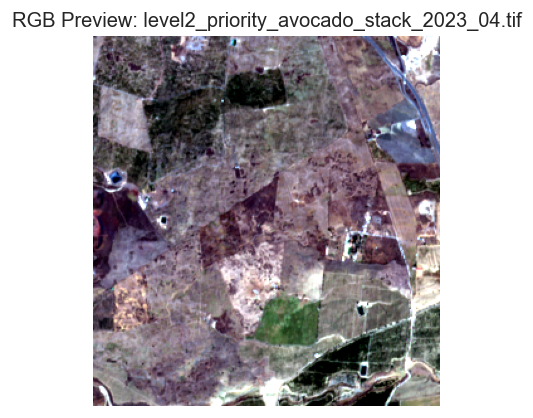

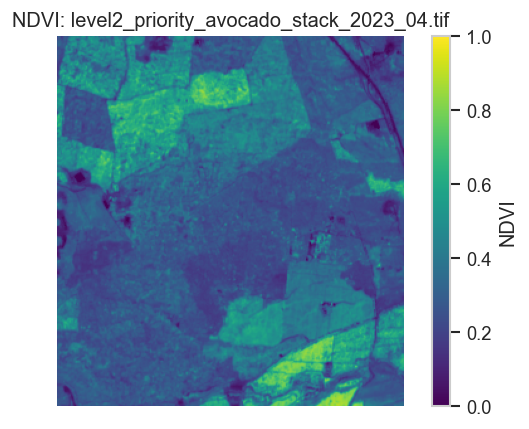

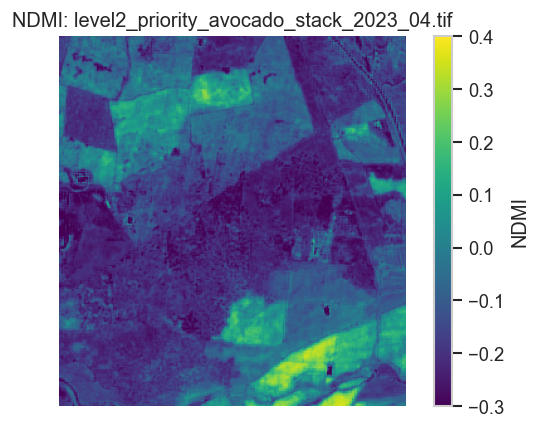

level2_priority_avocado_stack_2024_04.tif


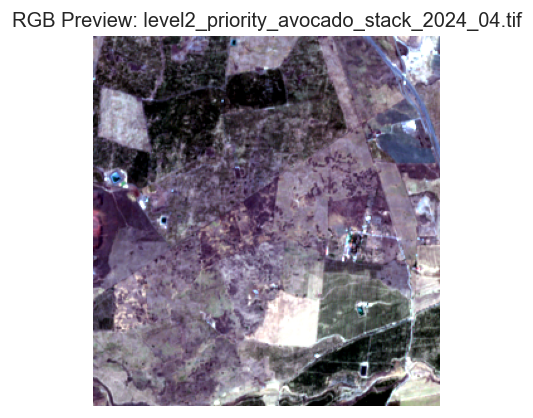

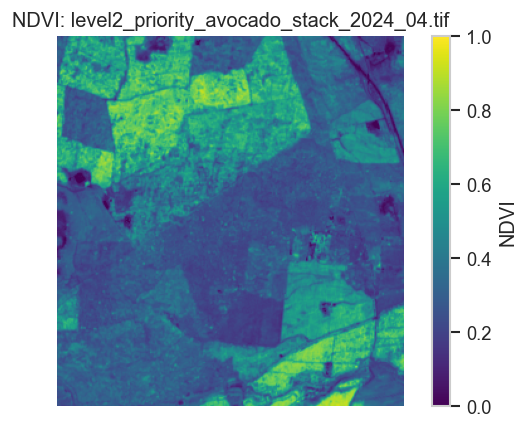

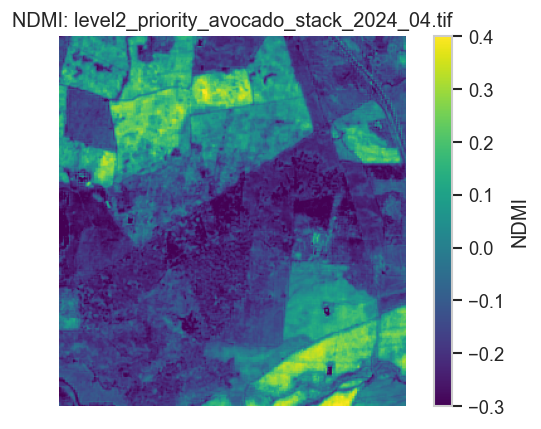

level2_priority_avocado_stack_2025_04.tif


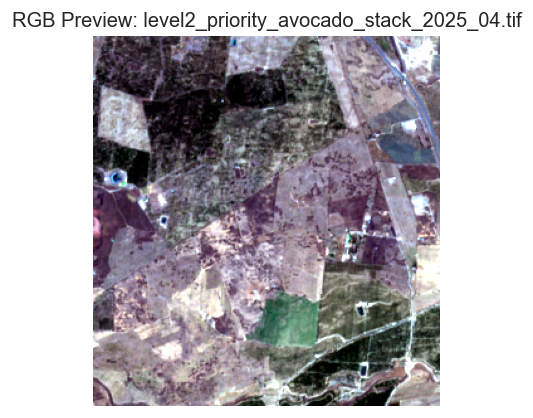

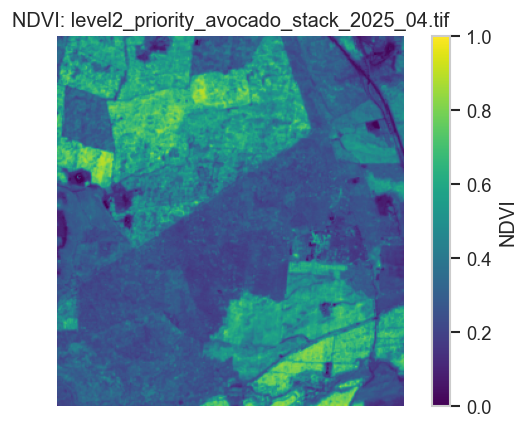

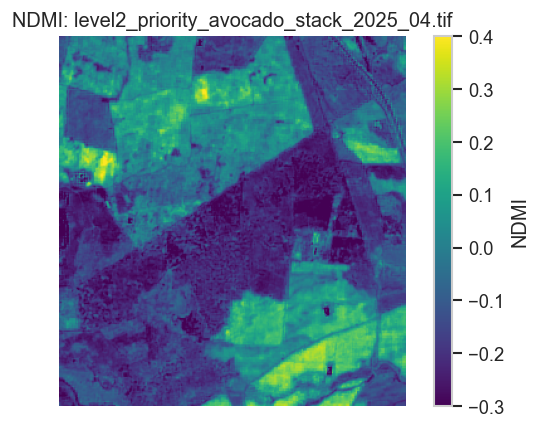

In [102]:
tif_files = sorted(geotiff_dir.glob("*.tif"))

for tif in tif_files:
    print(tif.name)
    plot_geotiff_stack(tif)

En RGB, se ven zonas agrícolas con diferentes tonos. Las áreas muy claras pueden ser suelo desnudo, caminos, infraestructura, plástico/invernaderos o superficies con alta reflectancia. Las zonas verdes/oscuras corresponden a vegetación más densa.

En NDVI, las zonas amarillas/verdes altas indican vegetación más vigorosa. Las zonas moradas/azules bajas pueden ser suelo, caminos, áreas urbanas, suelo seco o vegetación pobre. Eso es esperado.

En NDMI, las zonas más amarillas/verdes indican mayor contenido de humedad en la vegetación, mientras que las zonas moradas o azul oscuro indican menor humedad relativa. NDMI usa NIR y SWIR; Rasterio/documentación técnica lo trata como un índice útil para monitorear contenido de agua en vegetación, sequía e irrigación

---
## 5. Conclusiones

In [103]:
print('=== CONCLUSIONES EDA ===')
print('ESTRUCTURA:')
print('  • 100 parcelas, 4000 observaciones, 0 valores faltantes')
print('  • Período: 2023-2026, Área: ~47 km²')

print('ÍNDICES ESPECTRALES:')
print(f'  • NDVI: media={df["NDVI"].mean():.3f}, rango=[{df["NDVI"].min():.3f}, {df["NDVI"].max():.3f}]')
print(f'  • NDMI: media={df["NDMI"].mean():.3f}, rango=[{df["NDMI"].min():.3f}, {df["NDMI"].max():.3f}]')

print('CORRELACIÓN:')
print('  • NDVI–NDMI: r=0.7467 (correlación positiva moderada-alta)')
print('    → Las parcelas con mayor vigor tienden a presentar mayor humedad en el dosel. Casos con NDVI alto y NDMI bajo pueden indicar estrés hídrico.')

print('PATRONES TEMPORALES:')
print('  • NDVI máximo: Jun–Sep (meses lluviosos)')
print('  • NDVI mínimo: Feb–May (meses secos)')
print('  • Ciclo estacional claro y consistente')

# Calculamos distribución de clases de estrés usando df_class si existe
try:
    stress_counts = df_class['stress_class'].value_counts()
    total = len(df_class)
except Exception as e:
    stress_counts = {}
    total = 1
print('ESTRÉS HÍDRICO (etiqueta preliminar):')
for cls, cnt in stress_counts.items():
    pct = cnt / total * 100
    print(f'  • {cls}: {cnt} observaciones ({pct:.1f}%)')

print('PREPARADO PARA ML:')
print('  ✓ Datos limpios, validados y normalizados')
print('  ✓ Características seleccionadas: NDVI, NDMI, mes, año, coordenadas; variable objetivo preliminar: stress_class')


=== CONCLUSIONES EDA ===
ESTRUCTURA:
  • 100 parcelas, 4000 observaciones, 0 valores faltantes
  • Período: 2023-2026, Área: ~47 km²
ÍNDICES ESPECTRALES:
  • NDVI: media=0.508, rango=[0.040, 0.866]
  • NDMI: media=0.057, rango=[-0.263, 0.377]
CORRELACIÓN:
  • NDVI–NDMI: r=0.7467 (correlación positiva moderada-alta)
    → Las parcelas con mayor vigor tienden a presentar mayor humedad en el dosel. Casos con NDVI alto y NDMI bajo pueden indicar estrés hídrico.
PATRONES TEMPORALES:
  • NDVI máximo: Jun–Sep (meses lluviosos)
  • NDVI mínimo: Feb–May (meses secos)
  • Ciclo estacional claro y consistente
ESTRÉS HÍDRICO (etiqueta preliminar):
  • no_relative_stress: 3000 observaciones (75.0%)
  • moderate_possible_stress: 600 observaciones (15.0%)
  • severe_possible_stress: 400 observaciones (10.0%)
PREPARADO PARA ML:
  ✓ Datos limpios, validados y normalizados
  ✓ Características seleccionadas: NDVI, NDMI, mes, año, coordenadas; variable objetivo preliminar: stress_class


### 5.1 Exportar Dataset

In [104]:
output_path = r"C:\Users\omarh\Desktop\Maestria\df_eda_processed.csv"
df_norm.to_csv(output_path, index=False)

print(f'✓ Dataset procesado guardado')
print(f'  Archivo: df_eda_processed.csv')
print(f'  Dimensiones: {df_norm.shape[0]} x {df_norm.shape[1]}')

✓ Dataset procesado guardado
  Archivo: df_eda_processed.csv
  Dimensiones: 4000 x 13
